#### 프로젝트 : 기존 프로젝트 (Naive RAG) 개선 후 비교 

- Parameter
- new module
- new pattern
- 정량평가와 정성평가 적용

##### 순서 
- 기존 프로젝트 리팩토링
    - ~~RetrievalQA 구조 -> LCEL 구조 변경~~
    - 영문 데미안 -> 한글 자료 변경 : ing ...... 

- 평가 방법 적용
    - ~~정량 평가 : RAGAS (faithfulness, answer_relevancy, context_recall, context_precision)~~
    
    - 정성 평가 : <- 준비중......  
        - G-Eval / LLM-as-a-judge
        - Edge Case 까다로운 질문 비교하기 

- 성능 개선
    - 데이터 구조 
    - 인덱싱
    - 쿼리 최적화 
        - ~~Multi-Query Retriever : 개선 확인.~~ 
    - 임베딩
    - 생성
    - 증강
    - SoTA RAG

- 구조 변경 ? 
    - Naive -> Advanced -> Modular 

![image.png](attachment:image.png)

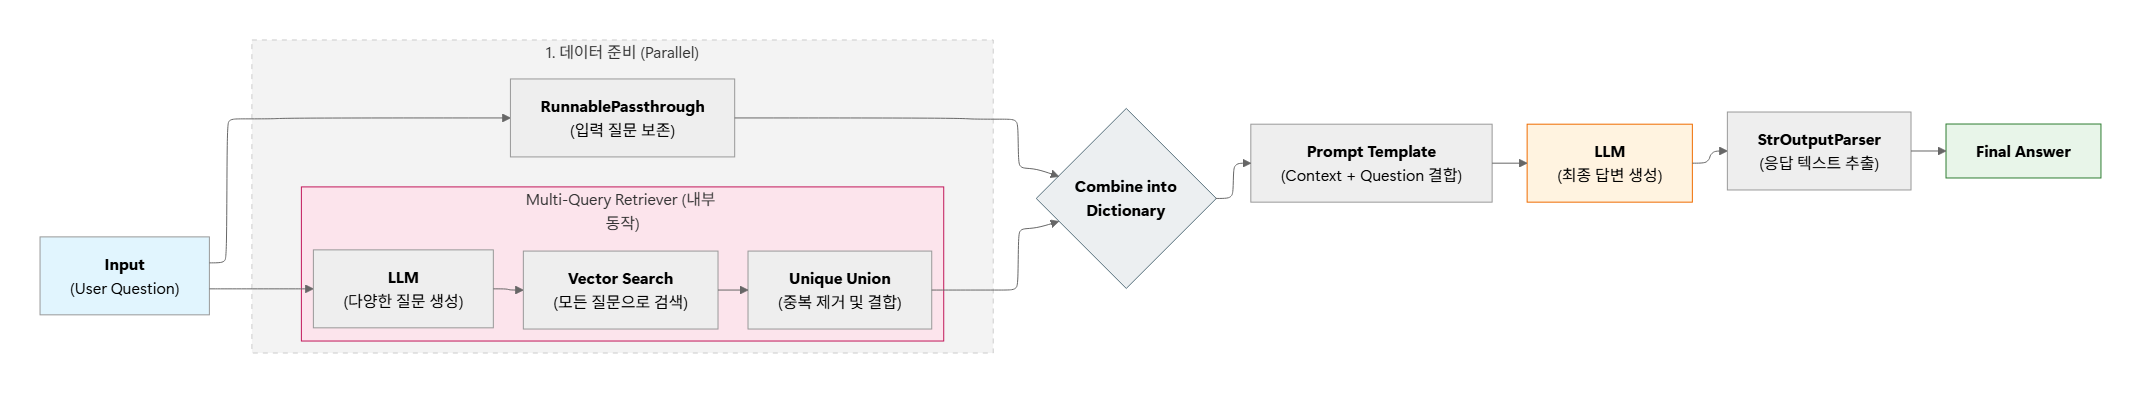

#### 1. RAGAS 평가 지표

##### 1. 검색 단계 (Retrieval) - 얼마나 잘 찾아왔는가
- **Context Precision**
    검색된 문서들 중 **실제 정답에 도움이 되는 내용이 상단에 배치되었는지**. 유용한 정보가 먼저 나올수록 점수가 높습니다.
- **Context Recall**
    필요한 **모든 정보가 검색된 결과 안에 포함되어 있는지**. 질문에 답하기 위해 1, 2, 3번 정보가 필요한데, 검색 결과에 1번만 있다면 재현율이 낮다고 판단합니다.
---
##### 2. 생성 단계 (Generation) - LLM이 답변을 얼마나 잘 만들었는가. 
- **Faithfulness**
    답변이 **검색된 컨텍스트 내용에만 기반하고 있는지**
- **Answer Relevancy**
    답변이 **사용자의 질문 의도에 얼마나 부합하는지**. (사실 답변이라도 질문과 상관 없으면 감점)

#### 1. Base Line 측정
| faithfulness | answer_relevancy | context_recall | context_precision |
|--------------|------------------|----------------|-------------------|
| 0.9667       | 0.8725           | 0.3333         | 0.7778            |

In [ ]:
import os
import nest_asyncio
import pandas as pd
import tiktoken
from dotenv import load_dotenv
from operator import itemgetter
from datasets import Dataset

from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.retrievers.multi_query import MultiQueryRetriever
from ragas import evaluate
from ragas.metrics.collections import (
    faithfulness, answer_relevancy, context_recall, context_precision,
)

class RAGProcessor:
    def __init__(self, file_path, model_name="gpt-4o", embedding_model_name="text-embedding-3-small", chunk_size=1000, chunk_overlap=100):
        load_dotenv()
        self.tokenizer = tiktoken.get_encoding("cl100k_base")
        self.llm = ChatOpenAI(model=model_name, temperature=0)
        self.embedding_model = OpenAIEmbeddings(model=embedding_model_name)
        
        # 문서 로드 및 분할
        loader = TextLoader(file_path)
        pages = loader.load() # TextLoader doesn't have load_and_split usually, it loads as a single document by default or multiple if specified

        
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size, 
            chunk_overlap=chunk_overlap, 
            length_function=self.tiktoken_len
        )
        self.texts = text_splitter.split_documents(pages)
        
        # 벡터스토어 빌드
        self.db = Chroma.from_documents(self.texts, self.embedding_model)
        
        # 프롬프트 템플릿
        template = """Answer the question based only on the following context:
{context}

Question: {question}

Answer:"""
        self.prompt = ChatPromptTemplate.from_template(template)

    def tiktoken_len(self, text):
        return len(self.tokenizer.encode(text))

    def get_baseline_chain(self, k=3):
        retriever = self.db.as_retriever(search_kwargs={"k": k})
        chain = (
            {"context": retriever, "question": RunnablePassthrough()}
            | self.prompt
            | self.llm
            | StrOutputParser()
        )
        return chain, retriever

    def get_improved_chain(self, k=3):
        base_retriever = self.db.as_retriever(search_kwargs={"k": k})
        retriever = MultiQueryRetriever.from_llm(
            retriever=base_retriever,
            llm=self.llm
        )
        chain = (
            {"context": retriever, "question": RunnablePassthrough()}
            | self.prompt
            | self.llm
            | StrOutputParser()
        )
        return chain, retriever

class RAGEvaluator:
    def __init__(self, llm=None, embeddings=None, embedding_model_name="text-embedding-3-small"):
        self.llm = llm or ChatOpenAI(model="gpt-4o", temperature=0)
        self.embeddings = embeddings or OpenAIEmbeddings(model=embedding_model_name)

    def run_eval(self, data_list):
        """
        data_list: list of dicts with keys ['question', 'answer', 'contexts', 'ground_truth']
        """
        ds = Dataset.from_dict({
            "question": [x["question"] for x in data_list],
            "answer": [x["answer"] for x in data_list],
            "contexts": [x["contexts"] for x in data_list],
            "ground_truth": [x["ground_truth"] for x in data_list]
        })
        return evaluate(
            ds, 
            metrics=[faithfulness, answer_relevancy, context_recall, context_precision],
            llm=self.llm,
            embeddings=self.embeddings
        )

In [1]:
# %load_ext autoreload
# %autoreload 2

import os
from practice_20260318_02 import *

/home/torious/anaconda3/envs/modulab2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if "__file__" in globals():
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    ROOT_DIR = os.getcwd()

file_path = os.path.join(ROOT_DIR, "data/Demian.pdf")

eval_questions = [
    "Who is Max Demian?",
    "What does the bird symbolize in the story?",
    "Describe the influence of Pistorius on Sinclair."
]
ground_truths = [
    "Max Demian is Sinclair's classmate and friend who leads him to self-realization and a deeper understanding of the world's duality.",
    "The bird emerging from the egg/globe symbolizes the soul breaking free from the conventional world to reach Abraxas.",
    "Pistorius is an organist and former theology student who teaches Sinclair about ancient myths and finding one's inner path."
]

In [ ]:
rag = RAGProcessor(file_path, 
    model_name="gpt-4o", 
    embedding_model_name="text-embedding-3-small", 
    chunk_size=1000, chunk_overlap=100)

evaluator = RAGEvaluator(llm=rag.llm, embeddings=rag.embedding_model)

In [ ]:
chain_b, retriever_b = rag.get_baseline_chain()

print("--- Running Pipeline ---")
results = []
for q, gt in zip(eval_questions, ground_truths):
    # Baseline
    ans_b = chain_b.invoke(q)
    ctx_b = [doc.page_content for doc in retriever_b.invoke(q)]
    results.append({"question": q, "answer": ans_b, "contexts": ctx_b, "ground_truth": gt, "type": "baseline"})

print("\n--- Evaluating Baseline ---")
res_b = evaluator.run_eval([r for r in results if r["type"] == "baseline"])
print(res_b)

--- Running Pipeline ---

--- Evaluating Baseline ---


Evaluating:   8%|▊         | 1/12 [00:02<00:30,  2.74s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating: 100%|██████████| 12/12 [00:24<00:00,  2.03s/it]


{'faithfulness': 0.9524, 'answer_relevancy': 0.9161, 'context_recall': 0.3333, 'context_precision': 0.8611}


#### 1. MultiQueryRetriever 적용
| faithfulness | answer_relevancy | context_recall | context_precision |
|--------------|------------------|----------------|-------------------|
| 1.0000       | 0.9097           | 1.0000         | 0.9444            |

In [ ]:
chain_i, retriever_i = rag.get_improved_chain()
print("--- Running Pipeline ---")
results = []
for q, gt in zip(eval_questions, ground_truths):       
    ans_i = chain_i.invoke(q)
    ctx_i = [doc.page_content for doc in retriever_i.invoke(q)]
    results.append({"question": q, "answer": ans_i, "contexts": ctx_i, "ground_truth": gt, "type": "improved"})

print("\n--- Evaluating Improved ---")
res_i = evaluator.run_eval([r for r in results if r["type"] == "improved"])
print(res_i)

--- Running Pipeline ---

--- Evaluating Improved ---


Evaluating:   8%|▊         | 1/12 [00:04<00:49,  4.52s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating: 100%|██████████| 12/12 [00:28<00:00,  2.38s/it]


{'faithfulness': 1.0000, 'answer_relevancy': 0.9003, 'context_recall': 0.6667, 'context_precision': 0.9722}
